In [1]:
"""
Этап 5. Матрица ABC/XYZ.

Соединяем два анализа (выручка + стабильность спроса)
и получаем 9 групп для стратегий управления.
"""
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2

ROOT_DIR = Path.cwd().parent
sys.path.append(str(ROOT_DIR))

from scripts.db_config import read_sql, execute_sql, _get_conn_params

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

REPORTS_DIR = ROOT_DIR / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

print("✅ Окружение готово")

✅ Окружение готово


In [2]:
# Забираем abc и xyz из Postgres
abc_xyz = read_sql("""
    SELECT
        a.stock_code,
        a.description,
        a.abc_category,
        COALESCE(x.xyz_category, 'N/A') AS xyz_category,
        a.revenue,
        a.revenue_share,
        a.total_quantity,
        a.orders,
        a.customers,
        a.active_months,
        x.mean_qty,
        x.std_qty,
        x.cv
    FROM abc a
    LEFT JOIN xyz x ON a.stock_code = x.stock_code;
""")

# Формируем объединённую группу ABC_XYZ
# Если xyz_category = 'N/A' (недостаточно данных) — отдельная группа
abc_xyz["abc_xyz"] = np.where(
    abc_xyz["xyz_category"] == "N/A",
    abc_xyz["abc_category"] + "-no_data",
    abc_xyz["abc_category"] + abc_xyz["xyz_category"],
)

# Приводим типы
abc_xyz["revenue"] = abc_xyz["revenue"].astype(float)
abc_xyz["total_quantity"] = abc_xyz["total_quantity"].astype(int)
abc_xyz["orders"] = abc_xyz["orders"].astype(int)
abc_xyz["customers"] = abc_xyz["customers"].astype(int)
abc_xyz["active_months"] = abc_xyz["active_months"].astype(int)

print(f"Всего строк: {len(abc_xyz):,}")
print(f"\nРаспределение по abc_xyz:")
display(abc_xyz["abc_xyz"].value_counts().to_frame("n"))

Всего строк: 4,895

Распределение по abc_xyz:


,n
abc_xyz,
CZ,2426
BZ,1012
AZ,516
AY,408
BY,250
CY,155
AX,110
BX,16
A-no_data,1


In [3]:
summary = (
    abc_xyz.groupby("abc_xyz", as_index=False)
    .agg(
        skus=("stock_code", "count"),
        revenue=("revenue", "sum"),
        quantity=("total_quantity", "sum"),
        orders=("orders", "sum"),
        customers=("customers", "sum"),
    )
)

total_skus = summary["skus"].sum()
total_revenue = summary["revenue"].sum()
total_qty = summary["quantity"].sum()

summary["sku_share_pct"] = summary["skus"] / total_skus * 100
summary["revenue_share_pct"] = summary["revenue"] / total_revenue * 100
summary["qty_share_pct"] = summary["quantity"] / total_qty * 100

# Упорядочим для красоты: A-группы сначала, потом B, потом C
order_map = {
    "AX": 1, "AY": 2, "AZ": 3, "A-no_data": 4,
    "BX": 5, "BY": 6, "BZ": 7,
    "CX": 8, "CY": 9, "CZ": 10,
}
summary["order"] = summary["abc_xyz"].map(order_map)
summary = summary.sort_values("order").drop(columns="order").reset_index(drop=True)

print("Сводка по группам ABC/XYZ:")
display(summary[[
    "abc_xyz", "skus", "sku_share_pct",
    "revenue", "revenue_share_pct",
    "quantity", "qty_share_pct",
    "orders", "customers",
]].round(2))

Сводка по группам ABC/XYZ:


,abc_xyz,skus,sku_share_pct,revenue,revenue_share_pct,quantity,qty_share_pct,orders,customers
0,AX,110,2.25,"2,883,259.37",14.34,1881108,16.50,134342,47461
1,AY,408,8.34,"7,068,488.82",35.15,3420547,30.00,300424,132992
2,AZ,516,10.54,"5,965,998.53",29.67,2540112,22.28,218955,115921
3,A-no_data,1,0.02,"168,469.60",0.84,80995,0.71,1,1
4,BX,16,0.33,"48,100.13",0.24,75113,0.66,7033,3139
5,BY,250,5.11,"619,843.37",3.08,601502,5.28,65414,32652
6,BZ,1012,20.67,"2,348,611.53",11.68,1731900,15.19,161416,93045
7,CX,1,0.02,897.12,0.00,1078,0.01,136,102
8,CY,155,3.17,"97,955.78",0.49,113801,1.00,15096,6510
9,CZ,2426,49.56,"907,409.47",4.51,956460,8.39,89142,49081


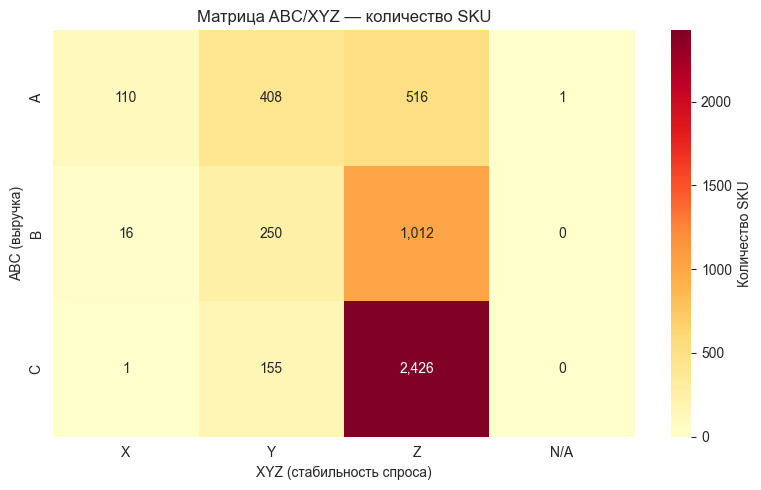

Матрица по SKU:


xyz_category,X,Y,Z,N/A
abc_category,,,,
A,110,408,516,1
B,16,250,1012,0
C,1,155,2426,0


In [10]:
# Pivot для heatmap: строки ABC, столбцы XYZ
matrix_sku = abc_xyz.pivot_table(
    index="abc_category",
    columns="xyz_category",
    values="stock_code",
    aggfunc="count",
    fill_value=0,
)

# Упорядочим
matrix_sku = matrix_sku.reindex(
    index=["A", "B", "C"],
    columns=["X", "Y", "Z", "N/A"],
    fill_value=0,
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    matrix_sku,
    annot=True,
    fmt=",d",
    cmap="YlOrRd",
    cbar_kws={"label": "Количество SKU"},
    ax=ax,
)
ax.set_title("Матрица ABC/XYZ — количество SKU")
ax.set_xlabel("XYZ (стабильность спроса)")
ax.set_ylabel("ABC (выручка)")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "abc_xyz_matrix_skus.png", dpi=120, bbox_inches="tight")
plt.show()

print("Матрица по SKU:")
display(matrix_sku)

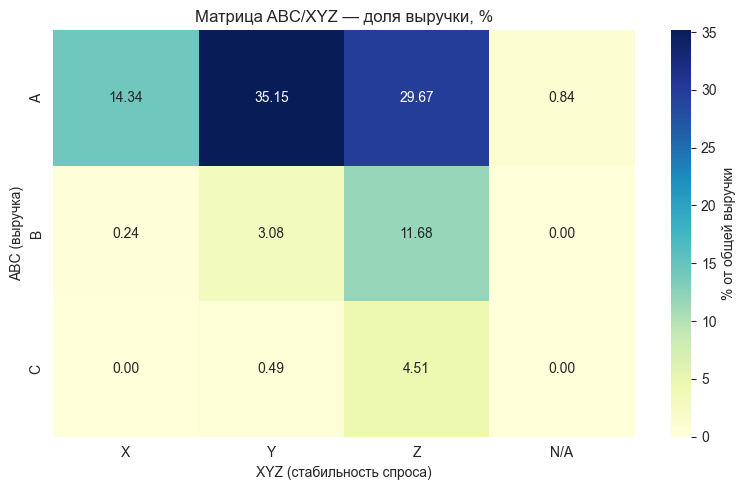

Матрица по выручке, % от общей:


xyz_category,X,Y,Z,N/A
abc_category,,,,
A,14.34,35.15,29.67,0.84
B,0.24,3.08,11.68,0.00
C,0.00,0.49,4.51,0.00


In [5]:
matrix_rev = abc_xyz.pivot_table(
    index="abc_category",
    columns="xyz_category",
    values="revenue",
    aggfunc="sum",
    fill_value=0,
)

matrix_rev = matrix_rev.reindex(
    index=["A", "B", "C"],
    columns=["X", "Y", "Z", "N/A"],
    fill_value=0,
)

# Доли в % от общей выручки
matrix_rev_pct = matrix_rev / matrix_rev.sum().sum() * 100

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    matrix_rev_pct,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={"label": "% от общей выручки"},
    ax=ax,
)
ax.set_title("Матрица ABC/XYZ — доля выручки, %")
ax.set_xlabel("XYZ (стабильность спроса)")
ax.set_ylabel("ABC (выручка)")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "abc_xyz_matrix_revenue.png", dpi=120, bbox_inches="tight")
plt.show()

print("Матрица по выручке, % от общей:")
display(matrix_rev_pct.round(2))

In [6]:
def show_group(cat: str, n: int = 10) -> pd.DataFrame:
    """Показать топ-N SKU группы по выручке."""
    return (
        abc_xyz[abc_xyz["abc_xyz"] == cat]
        .sort_values("revenue", ascending=False)
        .head(n)
        [[
            "stock_code", "description", "revenue",
            "orders", "customers", "active_months", "cv",
        ]]
    )

print("=" * 100)
print("AX — лидеры: высокая выручка + стабильный спрос")
print("=" * 100)
display(show_group("AX"))

print("\n" + "=" * 100)
print("AZ — высокий вклад, но нестабильный спрос (проверить!)")
print("=" * 100)
display(show_group("AZ"))

print("\n" + "=" * 100)
print("CZ — основная зона для проверки на вывод")
print("=" * 100)
display(show_group("CZ"))

AX — лидеры: высокая выручка + стабильный спрос


,stock_code,description,revenue,orders,customers,active_months,cv
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"263,109.67",5365,1490,25,0.3645572897072862
2,85099B,RED RETROSPOT JUMBO BAG,"183,454.83",3989,978,25,0.31244649671643926
10,22386,JUMBO BAG PINK WITH WHITE SPOTS,"77,111.91",2245,601,24,0.47012052053644043
12,20725,LUNCH BAG RED SPOTTY,"72,292.85",3056,845,25,0.26151794589894184
14,85099F,JUMBO BAG STRAWBERRY,"68,488.81",1830,549,25,0.3915455753590148
21,21931,JUMBO STORAGE BAG SUKI,"62,285.28",2329,546,25,0.26827477607033734
26,85099C,JUMBO BAG BAROQUE BLACK WHITE,"60,292.32",1868,506,25,0.27676974406024846
28,22411,JUMBO SHOPPER VINTAGE RED PAISLEY,"58,275.45",2192,658,24,0.4343180696992185
31,20914,SET/5 RED SPOTTY LID GLASS BOWLS,"53,415.31",2030,647,25,0.40548209237745675
34,21212,PACK OF 72 RETROSPOT CAKE CASES,"52,997.20",3118,1115,25,0.3053203243256028



AZ — высокий вклад, но нестабильный спрос (проверить!)


,stock_code,description,revenue,orders,customers,active_months,cv
6,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"123,141.54",2018,896,24,1.5522557384135895
8,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",247,138,9,4.5643175677663
11,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,"74,448.92",756,300,24,2.0279138647711057
17,23084,RABBIT NIGHT LIGHT,"66,964.99",994,450,8,2.879250420803464
19,22114,HOT WATER BOTTLE TEA AND SYMPATHY,"63,517.75",1583,626,21,1.2796593646047631
20,82484,WOOD BLACK BOARD ANT WHITE FINISH,"62,842.02",1176,451,21,1.1020255702114754
22,22910,PAPER CHAIN KIT VINTAGE CHRISTMAS,"61,721.99",1427,701,16,1.5772945418931275
24,22112,CHOCOLATE HOT WATER BOTTLE,"60,763.12",1721,631,25,1.163027793861648
30,22189,CREAM HEART CARD HOLDER,"54,598.73",1299,536,24,1.1179336928992505
35,22111,SCOTTIE DOG HOT WATER BOTTLE,"52,192.31",1689,717,25,1.233447956274877



CZ — основная зона для проверки на вывод


,stock_code,description,revenue,orders,customers,active_months,cv
2313,22102,MIRROR MOSAIC T-LIGHT HOLDER,"1,206.54",59,35,23,3.8580704101276173
2314,21396,RED SPOTTY EGG CUP,"1,205.25",77,45,6,2.20173126734986
2316,21130,COLOURFUL STANDING GNOME,"1,204.38",49,29,7,3.4956550031627014
2317,21366,MIRRORED WALL ART PHOTO FRAMES,"1,203.57",77,24,23,1.9253049751959064
2318,21650,ASSORTED TUTTI FRUTTI BRACELET,"1,203.52",197,84,23,1.0188595965899885
2320,23026,DRAWER KNOB VINTAGE GLASS STAR,"1,201.04",62,43,7,1.8313220908205645
2321,84815,SET OF 3 DANISH ROSE PLANTERS,"1,200.82",53,34,7,4.251909856322458
2322,84313B,BLUE TV TRAY TABLE,"1,198.00",83,24,17,1.3584015117592256
2323,84678,CLASSICAL ROSE SMALL VASE,"1,196.29",81,52,16,1.1677530295127043
2324,20934,SET/3 POT PLANT CANDLES,"1,195.97",74,44,17,1.4948122879369399


In [7]:
print("Особый случай: SKU 23843 (PAPER CRAFT, LITTLE BIRDIE)")
print("Продался только в декабре 2011 → исключён из XYZ")
print("=" * 100)
display(
    abc_xyz[abc_xyz["stock_code"] == "23843"][[
        "stock_code", "description", "abc_category", "xyz_category",
        "abc_xyz", "revenue", "orders", "customers", "active_months",
    ]]
)

Особый случай: SKU 23843 (PAPER CRAFT, LITTLE BIRDIE)
Продался только в декабре 2011 → исключён из XYZ


,stock_code,description,abc_category,xyz_category,abc_xyz,revenue,orders,customers,active_months
3,23843,"PAPER CRAFT , LITTLE BIRDIE",A,N/A,A-no_data,"168,469.60",1,1,1


In [8]:
abc_xyz_for_db = abc_xyz[[
    "stock_code", "description", "abc_category", "xyz_category", "abc_xyz",
    "revenue", "revenue_share", "total_quantity",
    "orders", "customers", "active_months",
    "mean_qty", "std_qty", "cv",
]].copy()

execute_sql("""
    DROP TABLE IF EXISTS abc_xyz;
    CREATE TABLE abc_xyz (
        stock_code        text PRIMARY KEY,
        description       text,
        abc_category      text,
        xyz_category      text,
        abc_xyz           text,
        revenue           numeric,
        revenue_share     numeric,
        total_quantity    bigint,
        orders            integer,
        customers         integer,
        active_months     integer,
        mean_qty          numeric,
        std_qty           numeric,
        cv                numeric
    );
""")

insert_sql = """
    INSERT INTO abc_xyz VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s);
"""
rows = [tuple(r) for r in abc_xyz_for_db.itertuples(index=False, name=None)]

with psycopg2.connect(**_get_conn_params()) as conn:
    with conn.cursor() as cur:
        cur.executemany(insert_sql, rows)
    conn.commit()

print(f"✅ Таблица abc_xyz сохранена ({len(rows):,} строк)")

# Проверка
display(read_sql("""
    SELECT abc_xyz, COUNT(*) AS n
    FROM abc_xyz
    GROUP BY abc_xyz
    ORDER BY abc_xyz;
"""))

✅ Таблица abc_xyz сохранена (4,895 строк)


,abc_xyz,n
0,A-no_data,1
1,AX,110
2,AY,408
3,AZ,516
4,BX,16
5,BY,250
6,BZ,1012
7,CX,1
8,CY,155
9,CZ,2426


In [9]:
# Загружаем CV и переопределяем категории
cv_data = read_sql("SELECT stock_code, cv FROM abc_xyz WHERE cv IS NOT NULL;")
cv_data["cv"] = cv_data["cv"].astype(float)

alt_xyz = np.select(
    [cv_data["cv"] <= 0.7, cv_data["cv"] <= 1.0],
    ["X", "Y"],
    default="Z",
)
cv_data["xyz_alt"] = alt_xyz

print("Сравнение порогов:")
print(f"  Оригинал (X ≤ 0.5): X={(cv_data['xyz_alt'] == 'X').sum()} "
      f"(порог 0.5 не меняем)")
print()
for cat in ["X", "Y", "Z"]:
    n_original = (read_sql(f"SELECT COUNT(*) AS n FROM abc_xyz WHERE xyz_category = '{cat}';")["n"].iloc[0])
    n_alt = (cv_data["xyz_alt"] == cat).sum()
    print(f"  {cat}: оригинал (≤0.5) = {n_original:>5,} SKU | альтернатив (≤0.7) = {n_alt:>5,} SKU")

Сравнение порогов:
  Оригинал (X ≤ 0.5): X=401 (порог 0.5 не меняем)

  X: оригинал (≤0.5) =   127 SKU | альтернатив (≤0.7) =   401 SKU
  Y: оригинал (≤0.5) =   813 SKU | альтернатив (≤0.7) =   539 SKU
  Z: оригинал (≤0.5) = 3,954 SKU | альтернатив (≤0.7) = 3,954 SKU


## Этап 5. Матрица ABC/XYZ — ВЫВОДЫ (финал)

### Методология
- Соединили `abc` и `xyz` по `stock_code`.
- Для каждой группы: SKU, выручка, quantity, заказы, клиенты.
- Отдельно выделили SKU с недостаточной историей (`A-no_data`).

### Итоговая матрица (SKU)

| ABC \ XYZ | X | Y | Z | N/A | Всего |
|-----------|---|---|-----|------|-------|
| **A** | 110 | 408 | 516 | 1 | 1 035 |
| **B** | 16 | 250 | 1 012 | 0 | 1 278 |
| **C** | 1 | 155 | 2 426 | 0 | 2 582 |
| **Всего** | 127 | 813 | 3 954 | 1 | 4 895 |

### Итоговая матрица (доля выручки, % от общей)

| ABC \ XYZ | X | Y | Z | N/A | Всего |
|-----------|---|---|-----|------|-------|
| **A** | **14.34%** | **35.15%** | **29.67%** | 0.84% | 79.99% |
| **B** | 0.24% | 3.08% | **11.68%** | — | 15.00% |
| **C** | 0.00% | 0.49% | 4.51% | — | 5.00% |
| **Всего** | 14.58% | 38.72% | 45.86% | 0.84% | 100% |

### Ключевые выводы

1. **Ядро бизнеса — AX + AY = 518 SKU (10.6% ассортимента).**
   Вместе дают **49.49% выручки** и **46.50% quantity**.
   Это группа безусловного приоритета:
   - **AX (110 SKU)** — стабильный спрос, постоянный запас.
     Примеры: 85123A WHITE HANGING HEART (CV 0.36), 85099B RED RETROSPOT JUMBO BAG (CV 0.31).
   - **AY (408 SKU)** — высокая выручка, сезонность/колебания.
     Примеры: 22423 REGENCY CAKESTAND, 22086 PAPER CHAIN KIT.

2. **Группа AZ — критичная зона риска.**
   **516 SKU (10.54%) дают 29.67% выручки**, но CV > 1.0.
   Это **треть A-выручки** — нельзя ни терять, ни планировать наивно.
   Примеры:
   - **23166 MEDIUM CERAMIC TOP STORAGE JAR** — CV 4.56, 9 активных месяцев, разовые оптовые закупки.
   - **23084 RABBIT NIGHT LIGHT** — CV 2.88, 8 активных месяцев, вероятно сезонный.
   - **22086 PAPER CHAIN KIT 50'S CHRISTMAS** — CV 1.55, сезонный.

3. **«Длинный хвост» — BZ + CZ = 3 438 SKU (70.23%)**
   дают только **16.19% выручки**.
   - **BZ (1 012 SKU)** — 11.68% выручки.
   - **CZ (2 426 SKU)** — 4.51% выручки. **Основная зона для сокращения ~20% SKU.**

4. **Группа CX — 1 SKU.** Низкая выручка, стабильный спрос. **Не удалять.**

5. **A-no_data (SKU 23843 PAPER CRAFT)** — топ-4 по выручке, но продался только в декабре 2011. Требует наблюдения.

6. **Итеративная очистка — важный урок.** После первой пересборки `sales`
   случайно отфильтровали **36 реальных товаров** на ~£165 450 через
   агрессивный regex по описанию (`%coffee%`, `%carriage%`, `%check%`).
   Все восстановлены после фикса. **Фильтровать только точечно по StockCode.**
   Diff-проверки через `LEFT JOIN`, а не `NOT IN`.

7. **Альтернативный порог X ≤ 0.7.** Расширяет X-группу с 127 до 401 SKU.
   Оставляем классический X ≤ 0.5 (как в ТЗ), упоминаем альтернативу.

### Что зафиксировано в базе
Таблица `abc_xyz` (4 895 строк) сохранена в Postgres.

### Графики
- `reports/abc_xyz_matrix_skus.png` — heatmap по SKU.
- `reports/abc_xyz_matrix_revenue.png` — heatmap по выручке.

### Что дальше
**Этап 6 (Стратегии управления):** 9 групп → конкретные бизнес-рекомендации.
**Этап 7 (Кандидаты на сокращение):** фильтры + финальный список.